# Note, DDF schedule subject to change depending on weather and updates to survey strategy

In [1]:
import numpy as np
import matplotlib.pylab as plt
%matplotlib inline
from grab_ddf_sched import grab_ddf_sched
import pandas as pd

In [2]:
# Check the telescope config, download the save file 
# that has planned DDF observations, return array.
# Will skip download if file already exists
ddf_array = grab_ddf_sched()

Using file ts_ddf_array_59de7d5.npz


In [3]:
# ddf_array is a ScheduledObservationArray object--defined here:
# https://github.com/lsst/rubin_scheduler/blob/main/rubin_scheduler/scheduler/utils/observation_array.py
ddf_array.dtype.names

('band',
 'scheduler_note',
 'observation_reason',
 'target_name',
 'moon_min_distance',
 'HA_max',
 'dec',
 'RA',
 'flush_by_mjd',
 'mjd',
 'HA_min',
 'exptime')

In [4]:
# Pretty pandas formatting.

# Note all angles (RA, dec, etc) are in radians.
# Hour Angle limits (HA_max, and HA_min) are in hours.

# Some values can be filled or altered at observations time. E.g., 
# the telescope rotation is typically set, and the RA and dec are shifted
# to a dithered position. The filter column will be filled with the 
# filter name used at the summit using the value in "band". 

# This array has all of the "observed" field set to False because
# we have not checked completed observations to see whish should
# be set to True. 
pd.DataFrame(ddf_array)

,band,scheduler_note,observation_reason,target_name,moon_min_distance,HA_max,dec,RA,flush_by_mjd,mjd,HA_min,exptime
0,u,DD:XMM_LSS,ddf_xmm_lss,ddf_xmm_lss,0.436332,3.0,-0.084067,0.620901,60995.145833,60993.145833,21.0,38.0
1,u,DD:XMM_LSS,ddf_xmm_lss,ddf_xmm_lss,0.436332,3.0,-0.084067,0.620901,60995.145833,60993.145833,21.0,38.0
2,u,DD:XMM_LSS,ddf_xmm_lss,ddf_xmm_lss,0.436332,3.0,-0.084067,0.620901,60995.145833,60993.145833,21.0,38.0
3,u,DD:XMM_LSS,ddf_xmm_lss,ddf_xmm_lss,0.436332,3.0,-0.084067,0.620901,60996.142361,60994.142361,21.0,38.0
4,u,DD:XMM_LSS,ddf_xmm_lss,ddf_xmm_lss,0.436332,3.0,-0.084067,0.620901,60996.142361,60994.142361,21.0,38.0
...,...,...,...,...,...,...,...,...,...,...,...,...
182790,z,DD:EDFS_b,ddf_edfs_b,ddf_edfs_b,0.436332,3.0,-0.830777,1.110029,61435.055555,61433.055555,21.0,30.0
182791,z,DD:EDFS_b,ddf_edfs_b,ddf_edfs_b,0.436332,3.0,-0.830777,1.110029,61435.055555,61433.055555,21.0,30.0
182792,z,DD:EDFS_b,ddf_edfs_b,ddf_edfs_b,0.436332,3.0,-0.830777,1.110029,61435.055555,61433.055555,21.0,30.0
182793,z,DD:EDFS_b,ddf_edfs_b,ddf_edfs_b,0.436332,3.0,-0.830777,1.110029,61435.055555,61433.055555,21.0,30.0


In [5]:
u_targets = np.unique(ddf_array["target_name"])

Text(0, 0.5, 'N observation')

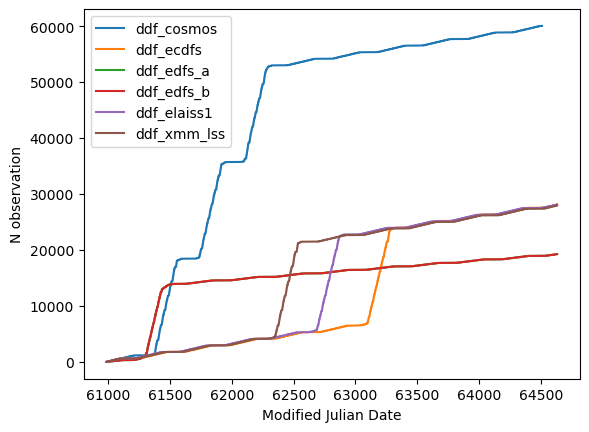

In [6]:
fig, ax = plt.subplots()
for target in u_targets:
    good = np.where(ddf_array["target_name"] == target)[0]
    num = np.arange(good.size)
    mjd = ddf_array["mjd"][good]
    ax.plot(np.sort(mjd), num, label=target)
ax.legend()
#plt.ylim([10,1e5])
ax.set_xlabel("Modified Julian Date")
ax.set_ylabel("N observation")